# Dipendenti pubblici 2010-2023 — validazione dati

Notebook tecnico. Genera le figure per il README e verifica i trend.

**Dataset**: `dipendenti_pubblici` (MEF-BDAP) via GCS clean parquet.
**Serie**: 2010-2023, 14 anni, 6 comparti.

Per la narrativa completa e i numeri chiave, vedi il [README](../README.md).


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display
pd.options.display.float_format = '{:,.0f}'.format
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = (10, 4.5)

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
GCS = 'gs://dataciviclab-clean/dipendenti_pubblici/*/dipendenti_pubblici_*_clean.parquet'

# Verifica copertura
anni = con.execute(f"SELECT DISTINCT anno FROM read_parquet('{GCS}') ORDER BY anno").fetchdf()
print(f"Anni: {list(anni['anno'])}")


Anni: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [2]:
# 1. Trend nazionale 2010-2023
trend = con.execute(f"""
    SELECT anno,
           CAST(SUM(donne_tempo_pieno + uomini_tempo_pieno
                     + donne_part_time_inf_50 + uomini_part_time_inf_50
                     + donne_part_time_sup_50 + uomini_part_time_sup_50) AS BIGINT) AS totale,
           CAST(SUM(donne_assunte + uomini_assunti) AS BIGINT) AS assunti,
           CAST(SUM(donne_cessate + uomini_cessati) AS BIGINT) AS cessati,
           CAST(SUM(donne_assunte + uomini_assunti)
                - SUM(donne_cessate + uomini_cessati) AS BIGINT) AS saldo_netto
    FROM read_parquet('{GCS}')
    GROUP BY anno
    ORDER BY anno
""").fetchdf()

display(trend.style.format('{:,.0f}'))

print(f"Minimo: {int(trend.loc[trend['totale'].idxmin(), 'totale']):,} ({int(trend.loc[trend['totale'].idxmin(), 'anno'])})")
print(f"Massimo: {int(trend.loc[trend['totale'].idxmax(), 'totale']):,} ({int(trend.loc[trend['totale'].idxmax(), 'anno'])})")


,anno,totale,assunti,cessati,saldo_netto
0,"2,010","3,315,347","131,382","179,523","-48,141"
1,"2,011","3,283,784","154,083","159,868","-5,785"
2,"2,012","3,238,949","86,722","138,251","-51,529"
3,"2,013","3,233,121","92,447","106,374","-13,927"
4,"2,014","3,259,613","104,012","122,321","-18,309"
5,"2,015","3,257,369","155,525","149,019","6,506"
6,"2,016","3,249,688","238,859","269,255","-30,396"
7,"2,017","3,244,994","183,953","204,155","-20,202"
8,"2,018","3,226,267","142,793","176,390","-33,597"
9,"2,019","3,245,112","167,027","188,574","-21,547"


Minimo: 3,226,267 (2018)
Massimo: 3,327,854 (2023)


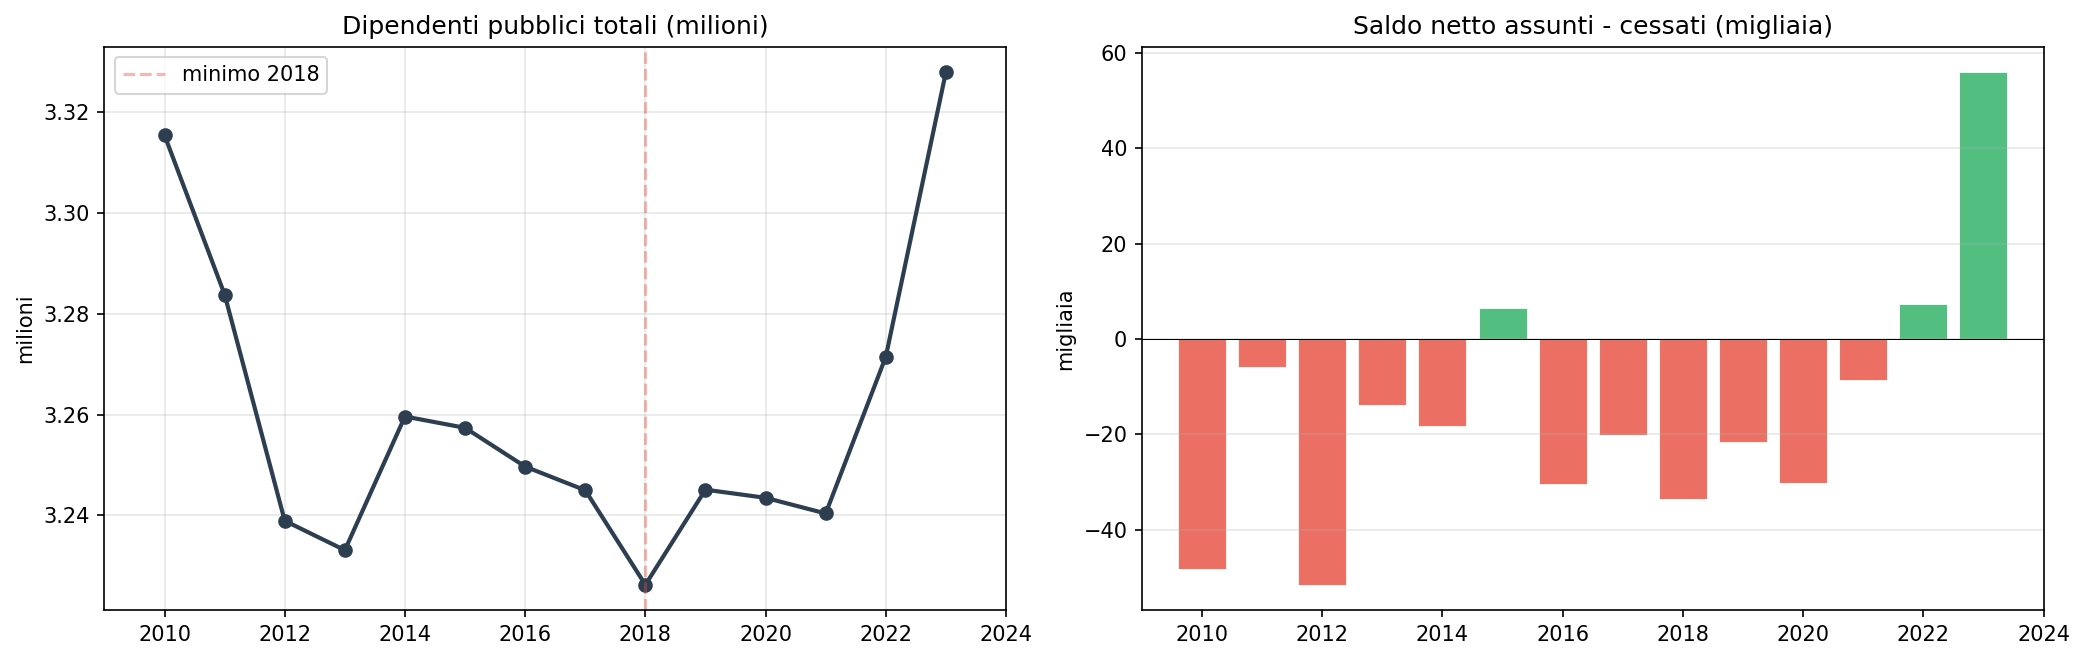

Salvato: figures/dipendenti_pubblici_v2_6_0.png


In [3]:
# Grafico: trend nazionale + saldo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.plot(trend['anno'], trend['totale'] / 1e6, marker='o', linewidth=2, color='#2c3e50')
ax1.axvline(x=2018, color='#e74c3c', linestyle='--', alpha=0.4, label='minimo 2018')
ax1.set_title('Dipendenti pubblici totali (milioni)', fontsize=12)
ax1.set_ylabel('milioni')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_xlim(2009, 2024)

colors = ['#27ae60' if v >= 0 else '#e74c3c' for v in trend['saldo_netto']]
ax2.bar(trend['anno'], trend['saldo_netto'] / 1000, color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_title('Saldo netto assunti - cessati (migliaia)', fontsize=12)
ax2.set_ylabel('migliaia')
ax2.grid(alpha=0.3, axis='y')
ax2.set_xlim(2009, 2024)

plt.tight_layout()
plt.savefig('../figures/dipendenti_pubblici_v2_6_0.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: figures/dipendenti_pubblici_v2_6_0.png')


In [4]:
# 2. Delta per comparto 2010 -> 2023
delta_comparti = con.execute(f"""
    SELECT comparto,
           CAST(SUM(CASE WHEN anno=2010 THEN donne_tempo_pieno + uomini_tempo_pieno
                              + donne_part_time_inf_50 + uomini_part_time_inf_50
                              + donne_part_time_sup_50 + uomini_part_time_sup_50 ELSE 0 END) AS BIGINT) AS anno_2010,
           CAST(SUM(CASE WHEN anno=2023 THEN donne_tempo_pieno + uomini_tempo_pieno
                              + donne_part_time_inf_50 + uomini_part_time_inf_50
                              + donne_part_time_sup_50 + uomini_part_time_sup_50 ELSE 0 END) AS BIGINT) AS anno_2023,
           CAST(SUM(CASE WHEN anno=2023 THEN donne_tempo_pieno + uomini_tempo_pieno
                              + donne_part_time_inf_50 + uomini_part_time_inf_50
                              + donne_part_time_sup_50 + uomini_part_time_sup_50 ELSE 0 END)
                - SUM(CASE WHEN anno=2010 THEN donne_tempo_pieno + uomini_tempo_pieno
                                + donne_part_time_inf_50 + uomini_part_time_inf_50
                                + donne_part_time_sup_50 + uomini_part_time_sup_50 ELSE 0 END) AS BIGINT) AS delta,
           ROUND((CAST(SUM(CASE WHEN anno=2023 THEN donne_tempo_pieno + uomini_tempo_pieno
                                    + donne_part_time_inf_50 + uomini_part_time_inf_50
                                    + donne_part_time_sup_50 + uomini_part_time_sup_50 ELSE 0 END) AS DOUBLE)
                 - CAST(SUM(CASE WHEN anno=2010 THEN donne_tempo_pieno + uomini_tempo_pieno
                                      + donne_part_time_inf_50 + uomini_part_time_inf_50
                                      + donne_part_time_sup_50 + uomini_part_time_sup_50 ELSE 0 END) AS DOUBLE))
                 / NULLIF(CAST(SUM(CASE WHEN anno=2010 THEN donne_tempo_pieno + uomini_tempo_pieno
                                             + donne_part_time_inf_50 + uomini_part_time_inf_50
                                             + donne_part_time_sup_50 + uomini_part_time_sup_50 ELSE 0 END) AS DOUBLE), 0) * 100, 1) AS var_pct
    FROM read_parquet('{GCS}')
    WHERE anno IN (2010, 2023)
    GROUP BY comparto
    ORDER BY delta DESC
""").fetchdf()

display(delta_comparti)

crescono = delta_comparti[delta_comparti['delta'] > 0]
calano = delta_comparti[delta_comparti['delta'] < 0]
print(f"Comparti in crescita: {crescono["delta"].sum():+,}")
print(f"Comparti in calo: {calano["delta"].sum():+,}")


,comparto,anno_2010,anno_2023,delta,var_pct
0,ISTRUZIONE E RICERCA,1128992,1306941,177949,16
1,COMPARTO AUTONOMO O FUORI COMPARTO,9184,41250,32066,349
2,SANITA',688484,701170,12686,2
3,PERSONALE IN REGIME DI DIRITTO PUBBLICO,618745,579322,-39423,-6
4,FUNZIONI CENTRALI,281316,205204,-76112,-27
5,FUNZIONI LOCALI,588626,493967,-94659,-16


Comparti in crescita: +222,701
Comparti in calo: -210,194


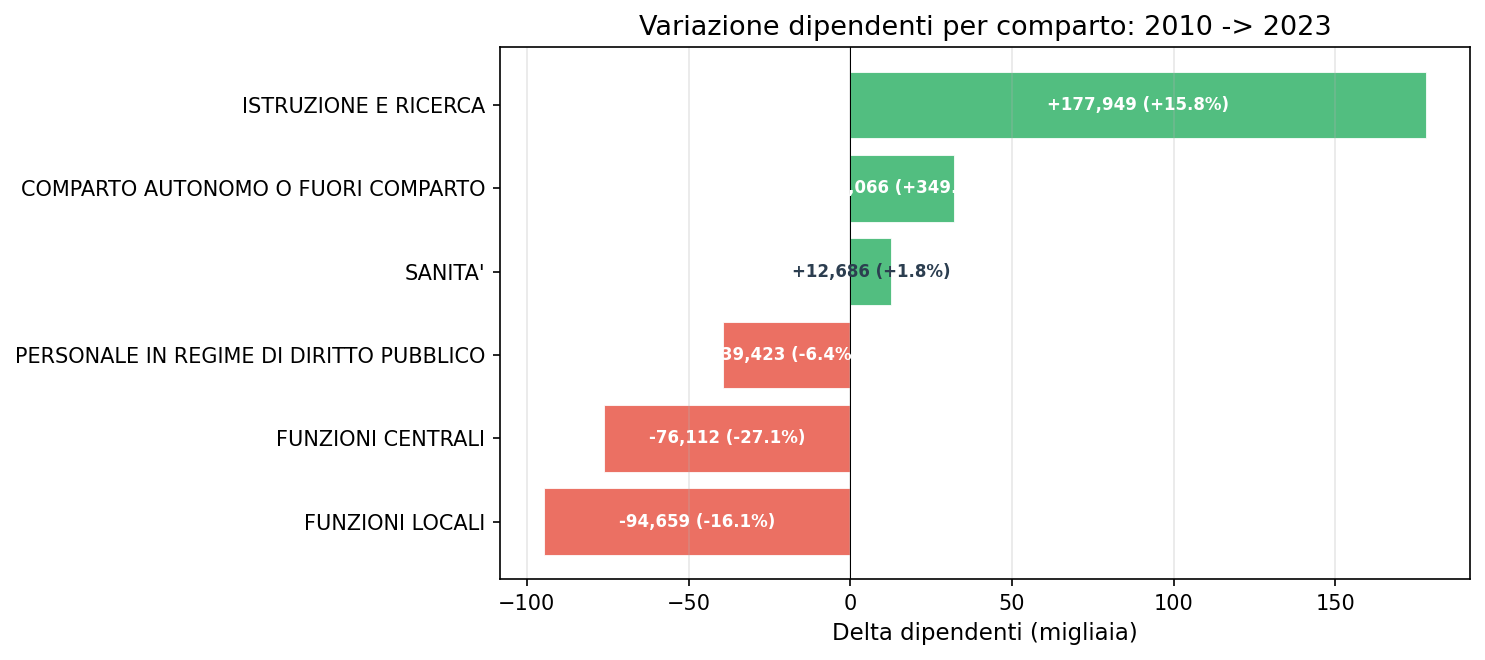

Salvato: figures/dipendenti_pubblici_v2_11_1.png


In [5]:
# Grafico: variazione per comparto
fig, ax = plt.subplots(figsize=(10, 4.5))
plot_data = delta_comparti.sort_values('delta')
colors = ['#27ae60' if d >= 0 else '#e74c3c' for d in plot_data['delta']]
bars = ax.barh(plot_data['comparto'], plot_data['delta'] / 1000, color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Delta dipendenti (migliaia)', fontsize=11)
ax.set_title('Variazione dipendenti per comparto: 2010 -> 2023', fontsize=13)
ax.grid(alpha=0.3, axis='x')

for bar, d, v in zip(bars, plot_data['delta'], plot_data['var_pct']):
    label = f"{d:+,} ({v:+.1f}%)"
    # Center text on bar with contrasting color
    text_color = 'white' if abs(d) > 20000 else '#2c3e50'
    if d >= 0:
        text_x = bar.get_width() / 2
    else:
        text_x = bar.get_x() + bar.get_width() / 2
    ax.text(text_x, bar.get_y() + bar.get_height()/2, label,
            ha='center', va='center', fontsize=8, color=text_color, weight='bold')

plt.tight_layout()
plt.savefig('../figures/dipendenti_pubblici_v2_11_1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: figures/dipendenti_pubblici_v2_11_1.png')


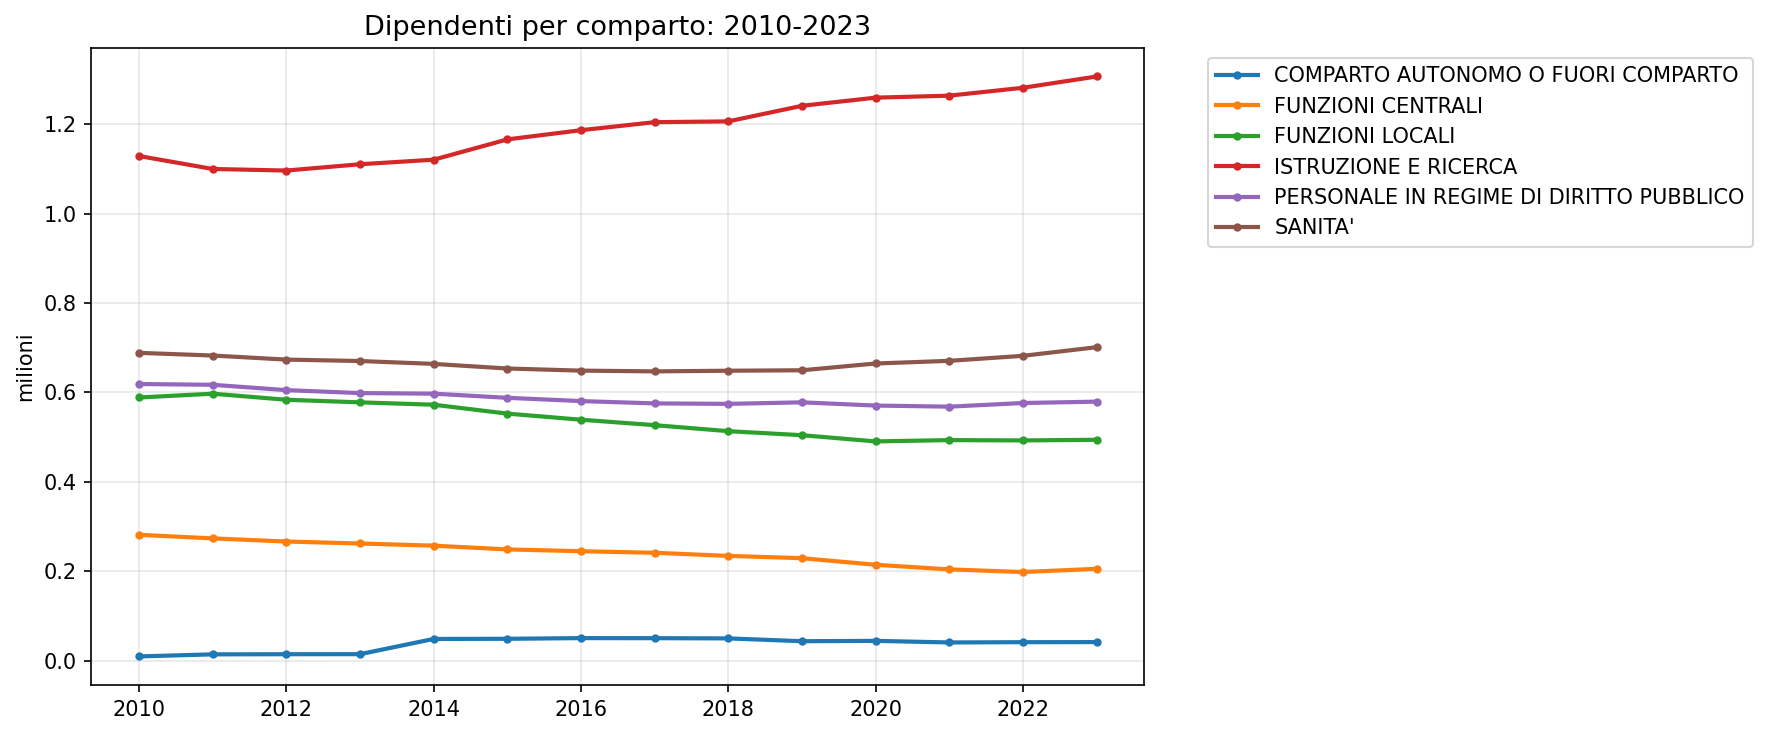

Salvato: figures/dipendenti_pubblici_v2_12_0.png


In [6]:
# 3. Serie storica per comparto
comparti_ts = con.execute(f"""
    SELECT anno, comparto,
           CAST(SUM(donne_tempo_pieno + uomini_tempo_pieno
                     + donne_part_time_inf_50 + uomini_part_time_inf_50
                     + donne_part_time_sup_50 + uomini_part_time_sup_50) AS BIGINT) AS totale
    FROM read_parquet('{GCS}')
    GROUP BY anno, comparto
    ORDER BY anno, comparto
""").fetchdf()

fig, ax = plt.subplots(figsize=(12, 5))
for comparto in comparti_ts['comparto'].unique():
    df_c = comparti_ts[comparti_ts['comparto'] == comparto]
    ax.plot(df_c['anno'], df_c['totale'] / 1e6, marker='.', label=comparto, linewidth=2)

ax.set_title('Dipendenti per comparto: 2010-2023', fontsize=13)
ax.set_ylabel('milioni')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/dipendenti_pubblici_v2_12_0.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: figures/dipendenti_pubblici_v2_12_0.png')


In [7]:
# 4. Focus 2023: assunzioni e saldo per comparto
tot_ass_2023 = con.execute(f"""
    SELECT CAST(SUM(donne_assunte + uomini_assunti) AS BIGINT) AS tot
    FROM read_parquet('{GCS}')
    WHERE anno = 2023
""").fetchdf()["tot"].iloc[0]

focus2023 = con.execute(f"""
    SELECT comparto,
           CAST(SUM(donne_assunte + uomini_assunti) AS BIGINT) AS assunti,
           CAST(SUM(donne_cessate + uomini_cessati) AS BIGINT) AS cessati,
           CAST(SUM(donne_assunte + uomini_assunti)
                - SUM(donne_cessate + uomini_cessati) AS BIGINT) AS saldo_netto,
           ROUND(CAST(SUM(donne_assunte + uomini_assunti) AS DOUBLE) * 100.0 / {tot_ass_2023}, 1) AS quota_assunzioni_pct
    FROM read_parquet('{GCS}')
    WHERE anno = 2023
    GROUP BY comparto
    ORDER BY saldo_netto DESC
""").fetchdf()

display(focus2023)

top2 = focus2023[focus2023['comparto'].isin(['SANITA\'', 'ISTRUZIONE E RICERCA'])]
tot_saldo = focus2023["saldo_netto"].sum()
print()
print(f"Totale assunzioni 2023: {tot_ass_2023:,}")
print(f"Sanita + Istruzione: {top2['assunti'].sum():,} assunzioni ({top2['quota_assunzioni_pct'].sum():.0f}%)")
print(f"Sanita + Istruzione: {top2['saldo_netto'].sum():,} saldo netto ({top2['saldo_netto'].sum()*100//tot_saldo}%)")


,comparto,assunti,cessati,saldo_netto,quota_assunzioni_pct
0,SANITA',90861,68738,22123,36
1,ISTRUZIONE E RICERCA,59639,38802,20837,24
2,FUNZIONI CENTRALI,20541,13658,6883,8
3,PERSONALE IN REGIME DI DIRITTO PUBBLICO,30815,27728,3087,12
4,FUNZIONI LOCALI,44533,41458,3075,18
5,COMPARTO AUTONOMO O FUORI COMPARTO,2217,2256,-39,1



Totale assunzioni 2023: 248,606
Sanita + Istruzione: 150,500 assunzioni (60%)
Sanita + Istruzione: 42,960 saldo netto (76%)


In [8]:
# 5. Quota donne per comparto (2023)
genere = con.execute(f"""
    SELECT comparto,
           CAST(SUM(donne_tempo_pieno + donne_part_time_inf_50 + donne_part_time_sup_50) AS BIGINT) AS donne,
           CAST(SUM(uomini_tempo_pieno + uomini_part_time_inf_50 + uomini_part_time_sup_50) AS BIGINT) AS uomini,
           ROUND(CAST(SUM(donne_tempo_pieno + donne_part_time_inf_50 + donne_part_time_sup_50) AS DOUBLE) * 100.0
                 / NULLIF(CAST(SUM(donne_tempo_pieno + uomini_tempo_pieno
                                   + donne_part_time_inf_50 + uomini_part_time_inf_50
                                   + donne_part_time_sup_50 + uomini_part_time_sup_50) AS DOUBLE), 0), 1) AS quota_donne_pct
    FROM read_parquet('{GCS}')
    WHERE anno = 2023
    GROUP BY comparto
    ORDER BY quota_donne_pct DESC
""").fetchdf()

display(genere)

femminili = genere[genere['quota_donne_pct'] >= 50]
maschili = genere[genere['quota_donne_pct'] < 50]
print(f"Comparti a maggioranza femminile: {len(femminili)}")
print(f"Comparti a maggioranza maschile: {len(maschili)}")


,comparto,donne,uomini,quota_donne_pct
0,ISTRUZIONE E RICERCA,1009242,297699,77
1,SANITA',486121,215049,69
2,FUNZIONI LOCALI,282856,211111,57
3,FUNZIONI CENTRALI,111732,93472,54
4,COMPARTO AUTONOMO O FUORI COMPARTO,19083,22167,46
5,PERSONALE IN REGIME DI DIRITTO PUBBLICO,79564,499758,14


Comparti a maggioranza femminile: 4
Comparti a maggioranza maschile: 2


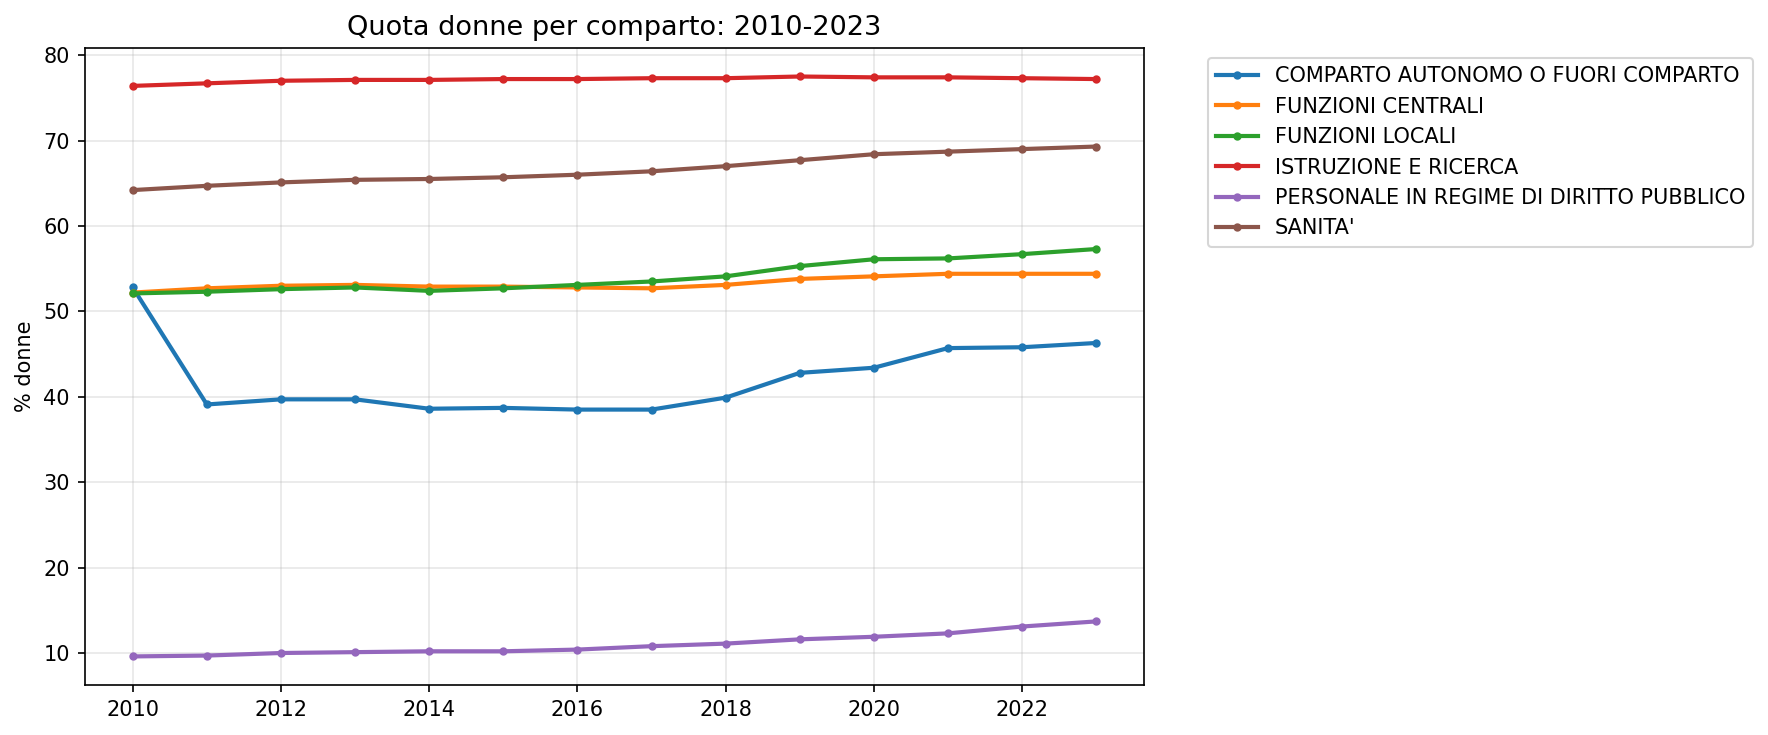

Salvato: figures/dipendenti_pubblici_v2_18_0.png


In [9]:
# 6. Evoluzione quota donne 2010-2023
genere_ts = con.execute(f"""
    SELECT anno, comparto,
           ROUND(CAST(SUM(donne_tempo_pieno + donne_part_time_inf_50 + donne_part_time_sup_50) AS DOUBLE) * 100.0
                 / NULLIF(CAST(SUM(donne_tempo_pieno + uomini_tempo_pieno
                                   + donne_part_time_inf_50 + uomini_part_time_inf_50
                                   + donne_part_time_sup_50 + uomini_part_time_sup_50) AS DOUBLE), 0), 1) AS quota_donne_pct
    FROM read_parquet('{GCS}')
    GROUP BY anno, comparto
    ORDER BY anno, comparto
""").fetchdf()

fig, ax = plt.subplots(figsize=(12, 5))
for comparto in genere_ts['comparto'].unique():
    df_g = genere_ts[genere_ts['comparto'] == comparto]
    ax.plot(df_g['anno'], df_g['quota_donne_pct'], marker='.', label=comparto, linewidth=2)

ax.set_title('Quota donne per comparto: 2010-2023', fontsize=13)
ax.set_ylabel('% donne')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/dipendenti_pubblici_v2_18_0.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: figures/dipendenti_pubblici_v2_18_0.png')


In [10]:
# Orario di lavoro
orario = con.execute(f"""
    SELECT anno,
           CAST(SUM(donne_tempo_pieno + uomini_tempo_pieno) AS BIGINT) AS tempo_pieno,
           CAST(SUM(donne_part_time_inf_50 + uomini_part_time_inf_50
                     + donne_part_time_sup_50 + uomini_part_time_sup_50) AS BIGINT) AS part_time,
           ROUND(CAST(SUM(donne_part_time_inf_50 + uomini_part_time_inf_50
                          + donne_part_time_sup_50 + uomini_part_time_sup_50) AS DOUBLE) * 100.0
                 / NULLIF(CAST(SUM(donne_tempo_pieno + uomini_tempo_pieno
                                   + donne_part_time_inf_50 + uomini_part_time_inf_50
                                   + donne_part_time_sup_50 + uomini_part_time_sup_50) AS DOUBLE), 0), 1) AS quota_pt_pct
    FROM read_parquet('{GCS}')
    GROUP BY anno
    ORDER BY anno
""").fetchdf()
display(orario)


,anno,tempo_pieno,part_time,quota_pt_pct
0,2010,3141024,174323,5
1,2011,3119524,164260,5
2,2012,3065502,173447,5
3,2013,3059345,173776,5
4,2014,3082891,176722,5
5,2015,3076158,181211,6
6,2016,3066081,183607,6
7,2017,3058399,186595,6
8,2018,3036102,190165,6
9,2019,3049060,196052,6


In [11]:
# === EXPORT SUMMARY JSON ===
import json, os

# Collezione di tutti i trend per il README
summary = {}

# 1. Trend nazionale
trend_json = trend.copy()
trend_json['totale'] = trend_json['totale'].astype(int)
trend_json['assunti'] = trend_json['assunti'].astype(int)
trend_json['cessati'] = trend_json['cessati'].astype(int)
trend_json['saldo_netto'] = trend_json['saldo_netto'].astype(int)
summary['trend_nazionale'] = trend_json.to_dict('records')

# 2. Punti salienti trend
min_val = int(trend.loc[trend['totale'].idxmin(), 'totale'])
min_year = int(trend.loc[trend['totale'].idxmin(), 'anno'])
max_val = int(trend.loc[trend['totale'].idxmax(), 'totale'])
max_year = int(trend.loc[trend['totale'].idxmax(), 'anno'])
summary['trend_punti'] = {
    'minimo': {'valore': min_val, 'anno': min_year},
    'massimo': {'valore': max_val, 'anno': max_year},
    'totale_2010': int(trend[trend['anno']==2010]['totale'].values[0]),
    'totale_2023': int(trend[trend['anno']==2023]['totale'].values[0]),
    'delta_2010_2023': int(trend[trend['anno']==2023]['totale'].values[0] - trend[trend['anno']==2010]['totale'].values[0]),
    'assunti_2023': int(trend[trend['anno']==2023]['assunti'].values[0]),
    'saldo_2023': int(trend[trend['anno']==2023]['saldo_netto'].values[0]),
}

# 3. Delta comparti
delta_json = delta_comparti.copy()
for col in ['anno_2010', 'anno_2023', 'delta']:
    delta_json[col] = delta_json[col].astype(int)
summary['comparti_delta'] = delta_json.to_dict('records')

# 4. Focus 2023
focus_json = focus2023.copy()
for col in ['assunti', 'cessati', 'saldo_netto']:
    focus_json[col] = focus_json[col].astype(int)
summary['focus_2023'] = focus_json.to_dict('records')

# 5. Genere
genere_json = genere.copy()
for col in ['donne', 'uomini']:
    genere_json[col] = genere_json[col].astype(int)
summary['genere'] = genere_json.to_dict('records')

# 6. Orario
orario_json = orario.copy()
for col in ['tempo_pieno', 'part_time']:
    orario_json[col] = orario_json[col].astype(int)
summary['orario'] = orario_json.to_dict('records')

# 7. Popolazione
summary["popolazione"] = {
    "pop_2023": 58997201,
    "dip_2023": 3327854,
    "rapporto_cittadini": 17,
    "pct_popolazione": 5.6,
    "sanita_per_cittadini": 84,
    "istruzione_per_cittadini": 45,
}

# Scrivi summary.json
out_path = '../figures/summary.json'
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f"✅ summary.json scritto in {out_path}")



✅ summary.json scritto in ../figures/summary.json


In [12]:
con.close()
print("Completato. 4 figure salvate in figures/")


Completato. 4 figure salvate in figures/
